# TASK 1. PROJECT OVERVIEW & KEY LEARNING OBJECTIVES

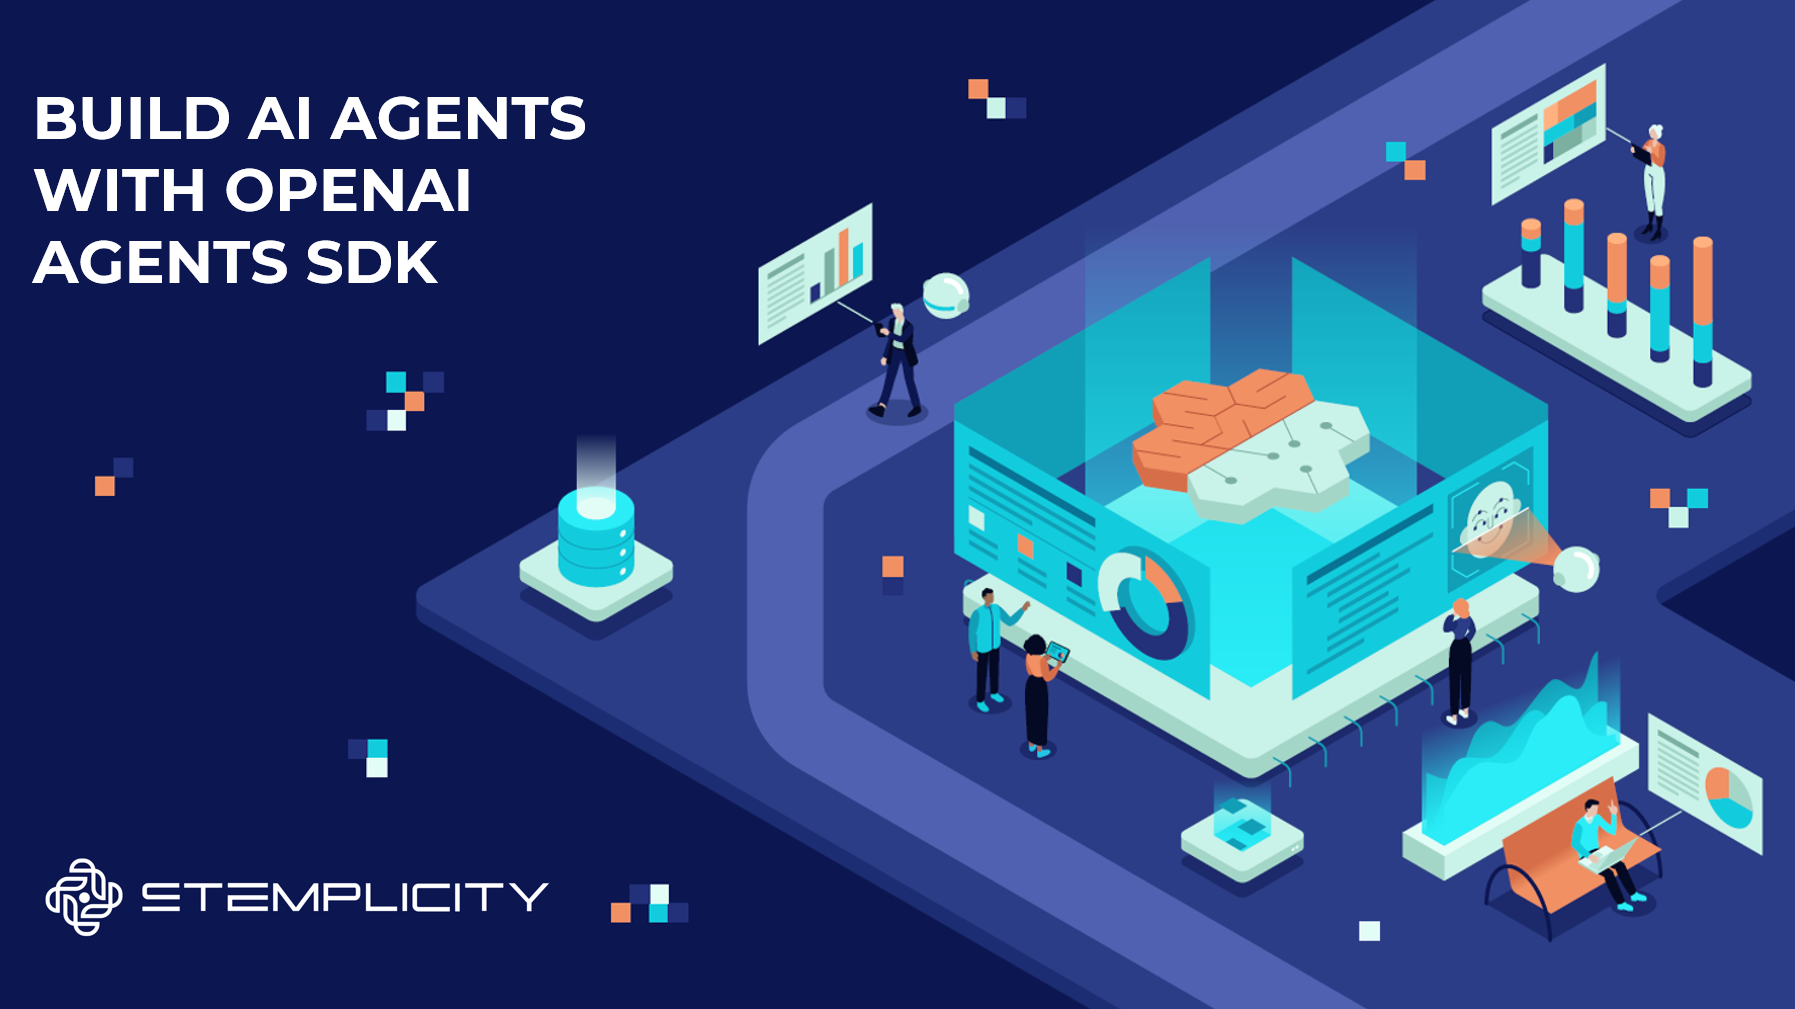

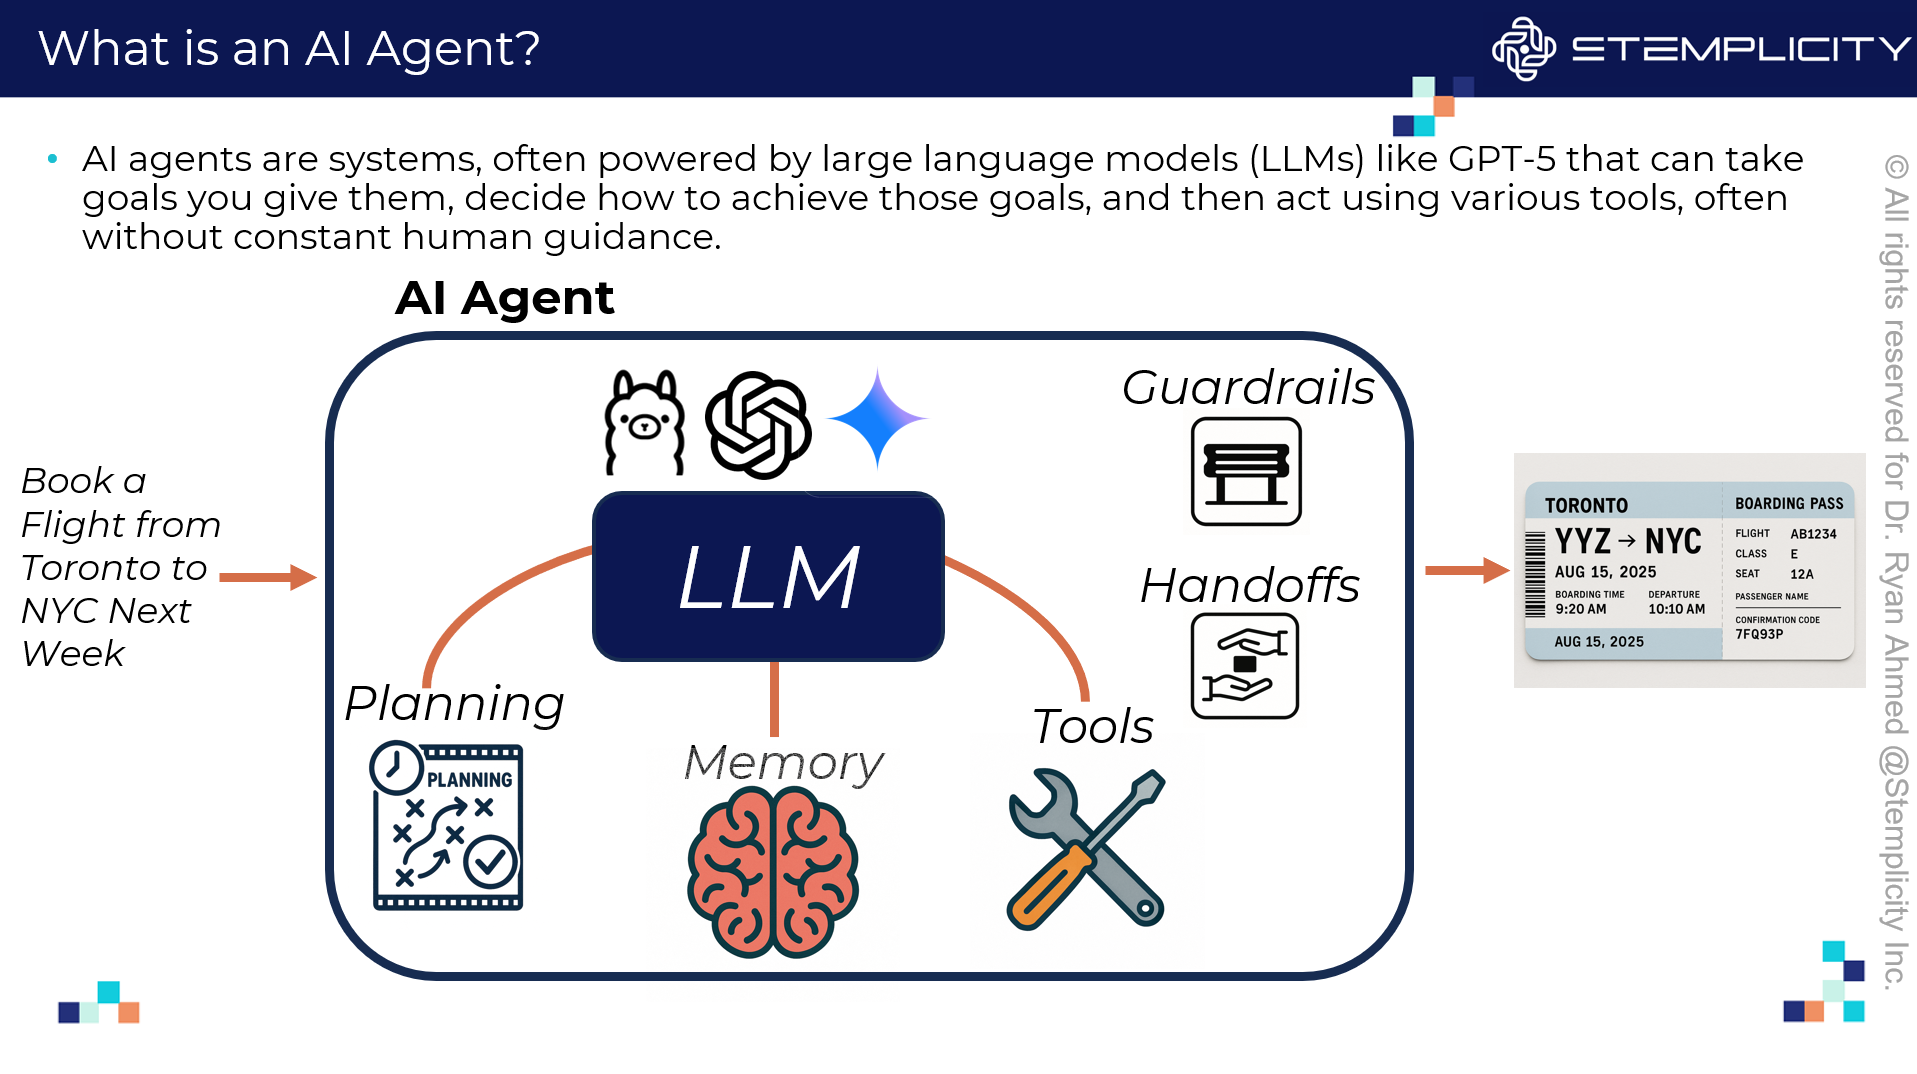

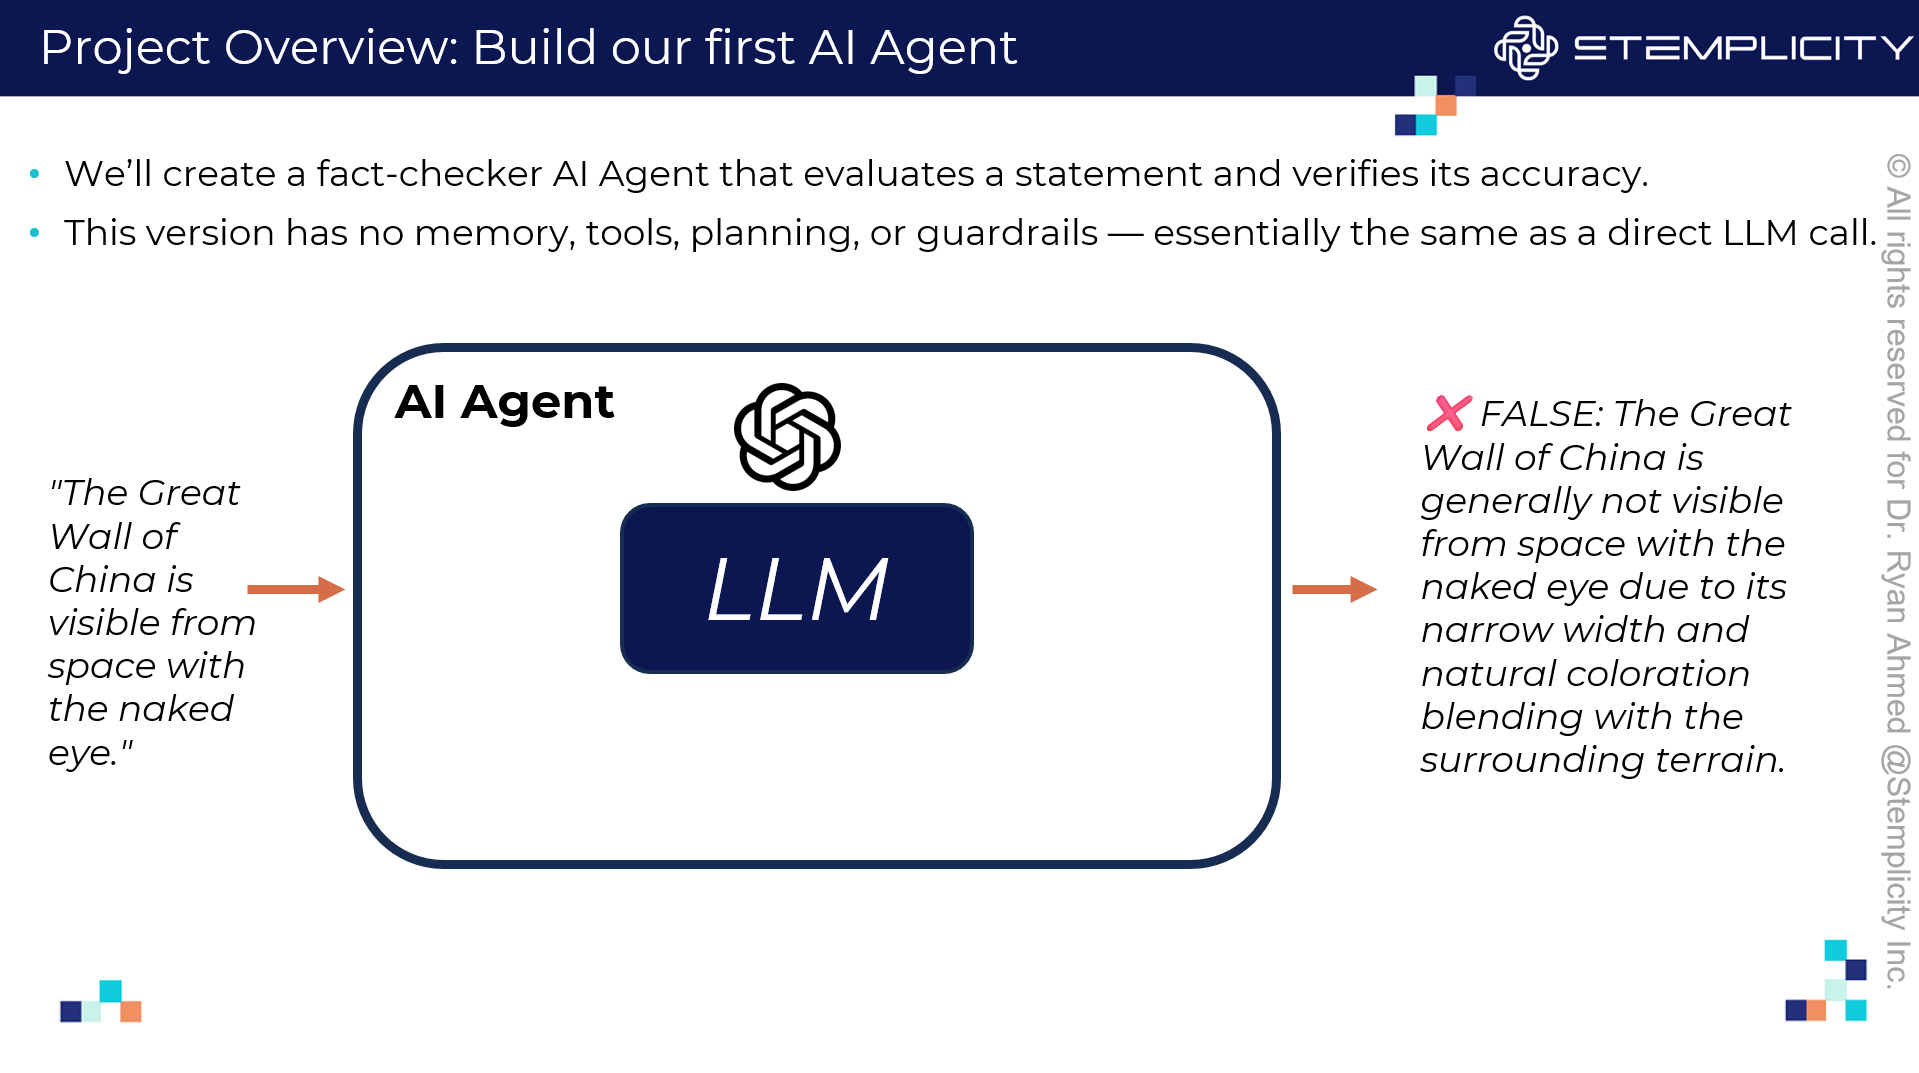

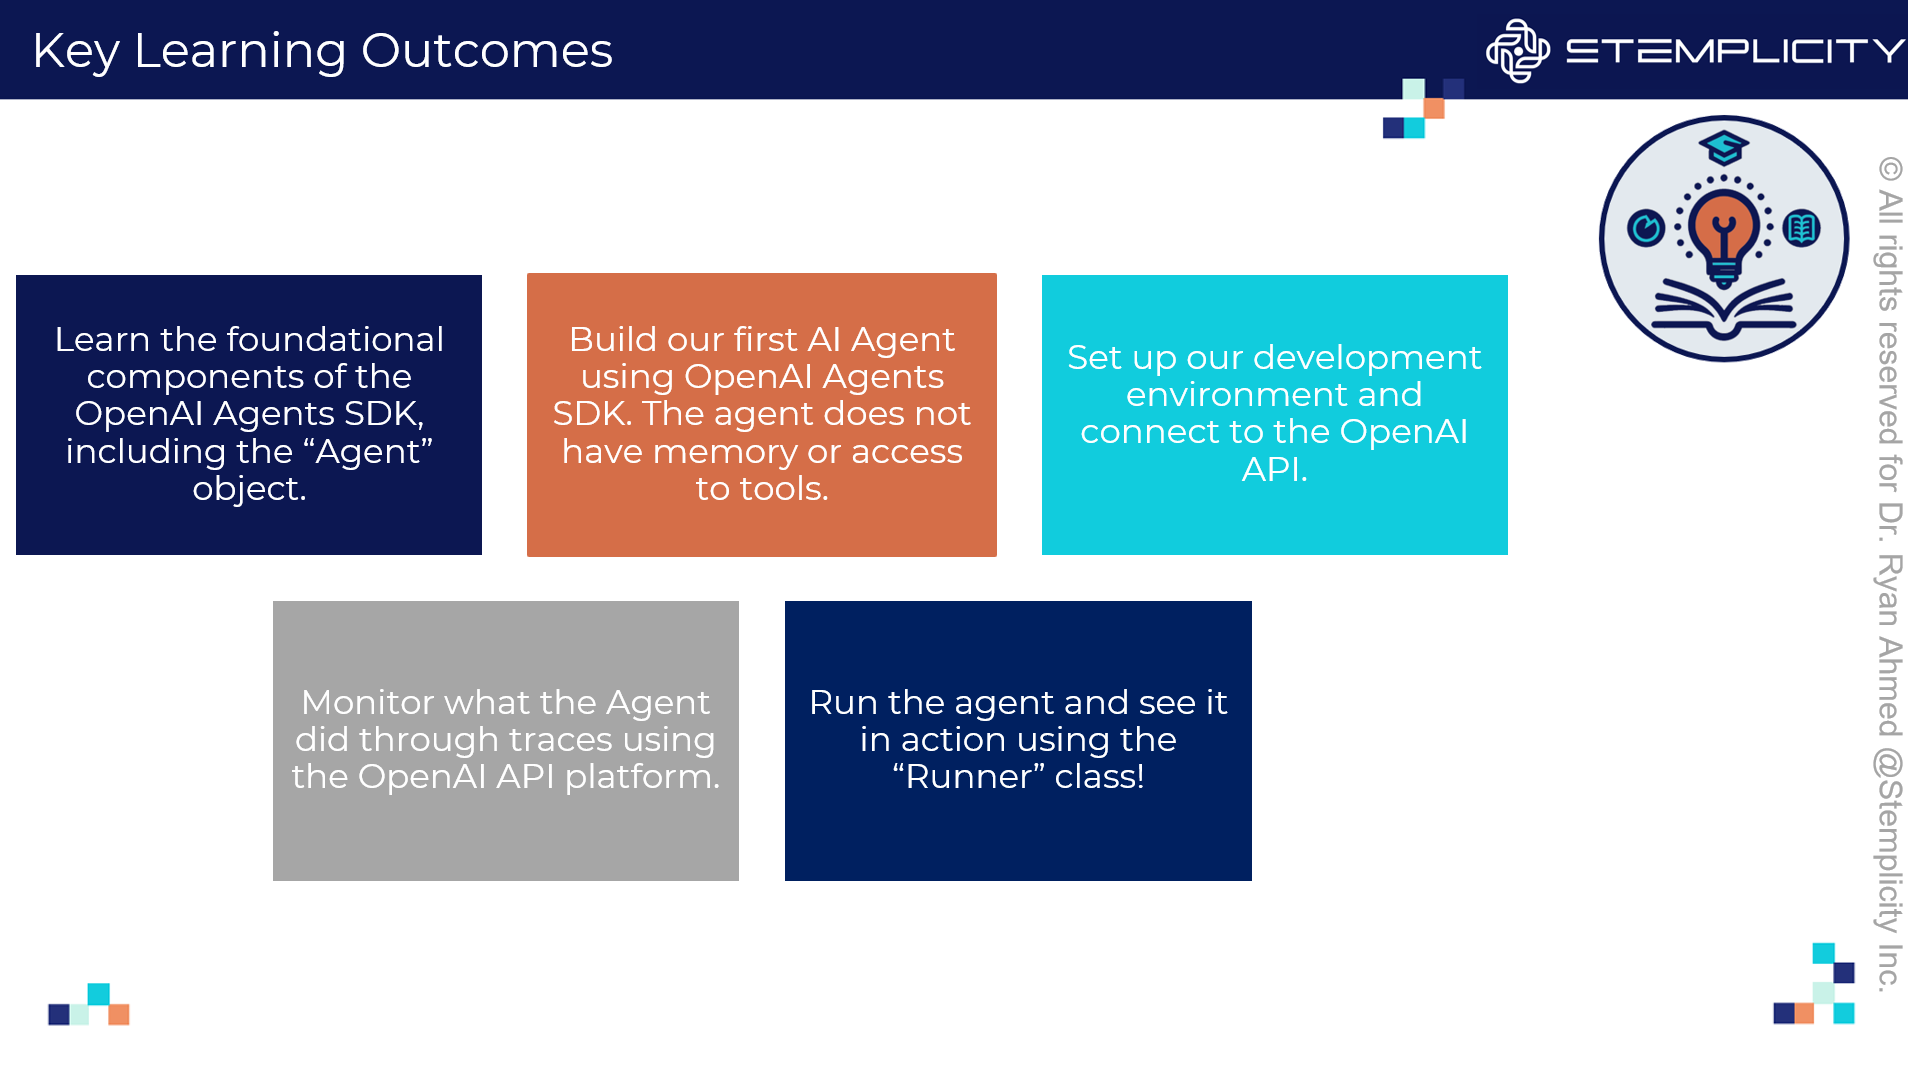

# TASK 2. SETTING UP YOUR ENVIRONMENT

Before we can build our first AI agent, we need two things:

1. The `openai-agents` library installed.  
2. Your secret OpenAI API key to communicate with the AI models.

> **Security tip 📌** Store keys securely in a `.env` file. Make sure you have a file named `.env` in the same directory as this notebook with your key:
>
> ```dotenv
> OPENAI_API_KEY=sk-YourSecretOpenAIKeyGoesHereXXXXXXXXXXXXX
> ```

Let's run the cells below to install the necessary packages and load your API key.

- **You can access the OpenAI API here: https://openai.com/api/**

In [1]:
# Uninstall openai-agents - if you have it installed
# Note that an SDK stands for "software development kit" which is a toolbox for building software for a specific platform or service.
!pip uninstall -y openai-agents

In [2]:
# Install the specific version of openai-agents
!pip install --no-cache-dir openai-agents==0.2.2

   ---------------------------------------- 0.0/948.6 kB ? eta -:--:--
   ---------------------------------------- 948.6/948.6 kB 25.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 36.5 MB/s  0:00:00
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------------------------------- 3.8/3.8 MB 31.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------------------------------- ---- 6.3/7.0 MB 29.8 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 29.7 MB/s  0:00:00
   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   ---------------------------------------- 676.6/676.6 kB 66.9 MB/s  0:00:00

   ----------------------------------------  0/40 [urllib3]
   ----------------------------------------  0/40 [urllib3]
   -- -------------------------------------  2/40 [tqdm]
   -- ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [3]:
# Install required Python packages:
# langchain-openai==0.2.1: a specific version of LangChain’s OpenAI integration library
# LangChain is a framework that makes it easier to build applications powered by large language models 
# It provides tools to connect to AI models, store context, and chain multiple steps together.
!pip install python-dotenv langchain-openai==0.2.1

# Upgrade the Pydantic library (used for validating and organizing data)  
# This ensures compatibility with the installed packages above  
!pip install --upgrade pydantic

   ---------------------------------------- 0.0/657.9 kB ? eta -:--:--
   ---------------------------------------- 657.9/657.9 kB 9.6 MB/s  0:00:00
   ---------------------------------------- 0.0/918.7 kB ? eta -:--:--
   ---------------------------------------- 918.7/918.7 kB 26.0 MB/s  0:00:00

   -- -------------------------------------  1/16 [xxhash]
   ----- ----------------------------------  2/16 [websockets]
   ----- ----------------------------------  2/16 [websockets]
   ----- ----------------------------------  2/16 [websockets]
   ---------- -----------------------------  4/16 [tenacity]
   ------------ ---------------------------  5/16 [regex]
   --------------- ------------------------  6/16 [PyYAML]
  Attempting uninstall: packaging
   --------------- ------------------------  6/16 [PyYAML]
    Found existing installation: packaging 26.2
   --------------- ------------------------  6/16 [PyYAML]
    Uninstalling packaging-26.2:
   --------------- ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
# Let's import "os" module, which stands for "Operating System"
# The os module in Python provides a way to interact with the operating system for things like:
# (1) accessing Environment Variables
# (2) Creating, renaming, and deleting files/folders.
import os
from openai import OpenAI
from IPython.display import display, Markdown

# This will be used to load the API key from the .env file
from dotenv import load_dotenv
load_dotenv()

# Get the OpenAI API keys from environment variables
# openai_api_key = os.getenv("OPENAI_API_KEY") -> We are using OpenRouter API Key with OpenAI Agent SDk.

# Get the OpenRouter API keys from environment variables
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")

# Let's view the first few characters in the key
print(openrouter_api_key[:5])


sk-or


In [ ]:
# DO NOT RUN this cell if using OpenRouter API Key
# Let's configure the OpenAI Client using our key
openai_client = OpenAI(api_key = openai_api_key)
print("OpenAI client successfully configured.")

# Let's view the first few characters in the key
print(openai_api_key[:5])

### CRITICAL: OpenRouter COnfiguration

Configure OPENAI Agent SDK to use OpenRouter API key and point to OpenRouter URL. <br>
`Do NOT RUN` this cell if using OPENAI API keys

In [16]:
import asyncio
from openai import AsyncOpenAI
from agents import set_default_openai_client, set_default_openai_api, set_tracing_disabled

# 1. Create a custom async client pointing to OpenRouter
or_client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=openrouter_api_key
)
    
# 2. Inject it into the Agents SDK
set_default_openai_client(or_client)
    
# 3. CRITICAL: Force the SDK to use Chat Completions 
# (OpenRouter does not support OpenAI's proprietary Responses API)
set_default_openai_api("chat_completions")

# 4. Disable telemetry to prevent the 401 error
set_tracing_disabled(True)

In [12]:
# A Function used to Show the given text using Markdown formatting in a Jupyter notebook
def print_markdown(text):
    """Displays text as Markdown in Jupyter."""
    display(Markdown(text))

# TASK 3. BUILD & RUN YOUR FIRST AI AGENT USING OPENAI AGENT SDK

It's time to build our first agent! We will use the `Agent` class from the `openai-agents` library.

Creating an agent is like hiring an employee. You need to provide a **job description**. The key parameters are:

* **client** – The OpenAI client we just configured. This is the agent's connection to the AI brain.  
* **name** – A simple name to identify your agent (e.g., "Fact Checker").  
* **instructions** – The most important part. It's the "system prompt" or the detailed job description for the agent. This tells the agent who to be and what to do.  
* **model** – The specific OpenAI model the agent will use (e.g., `gpt-4o-mini` is fast and cost‑effective or use the latest `gpt-5` for enhanced results and longer context).

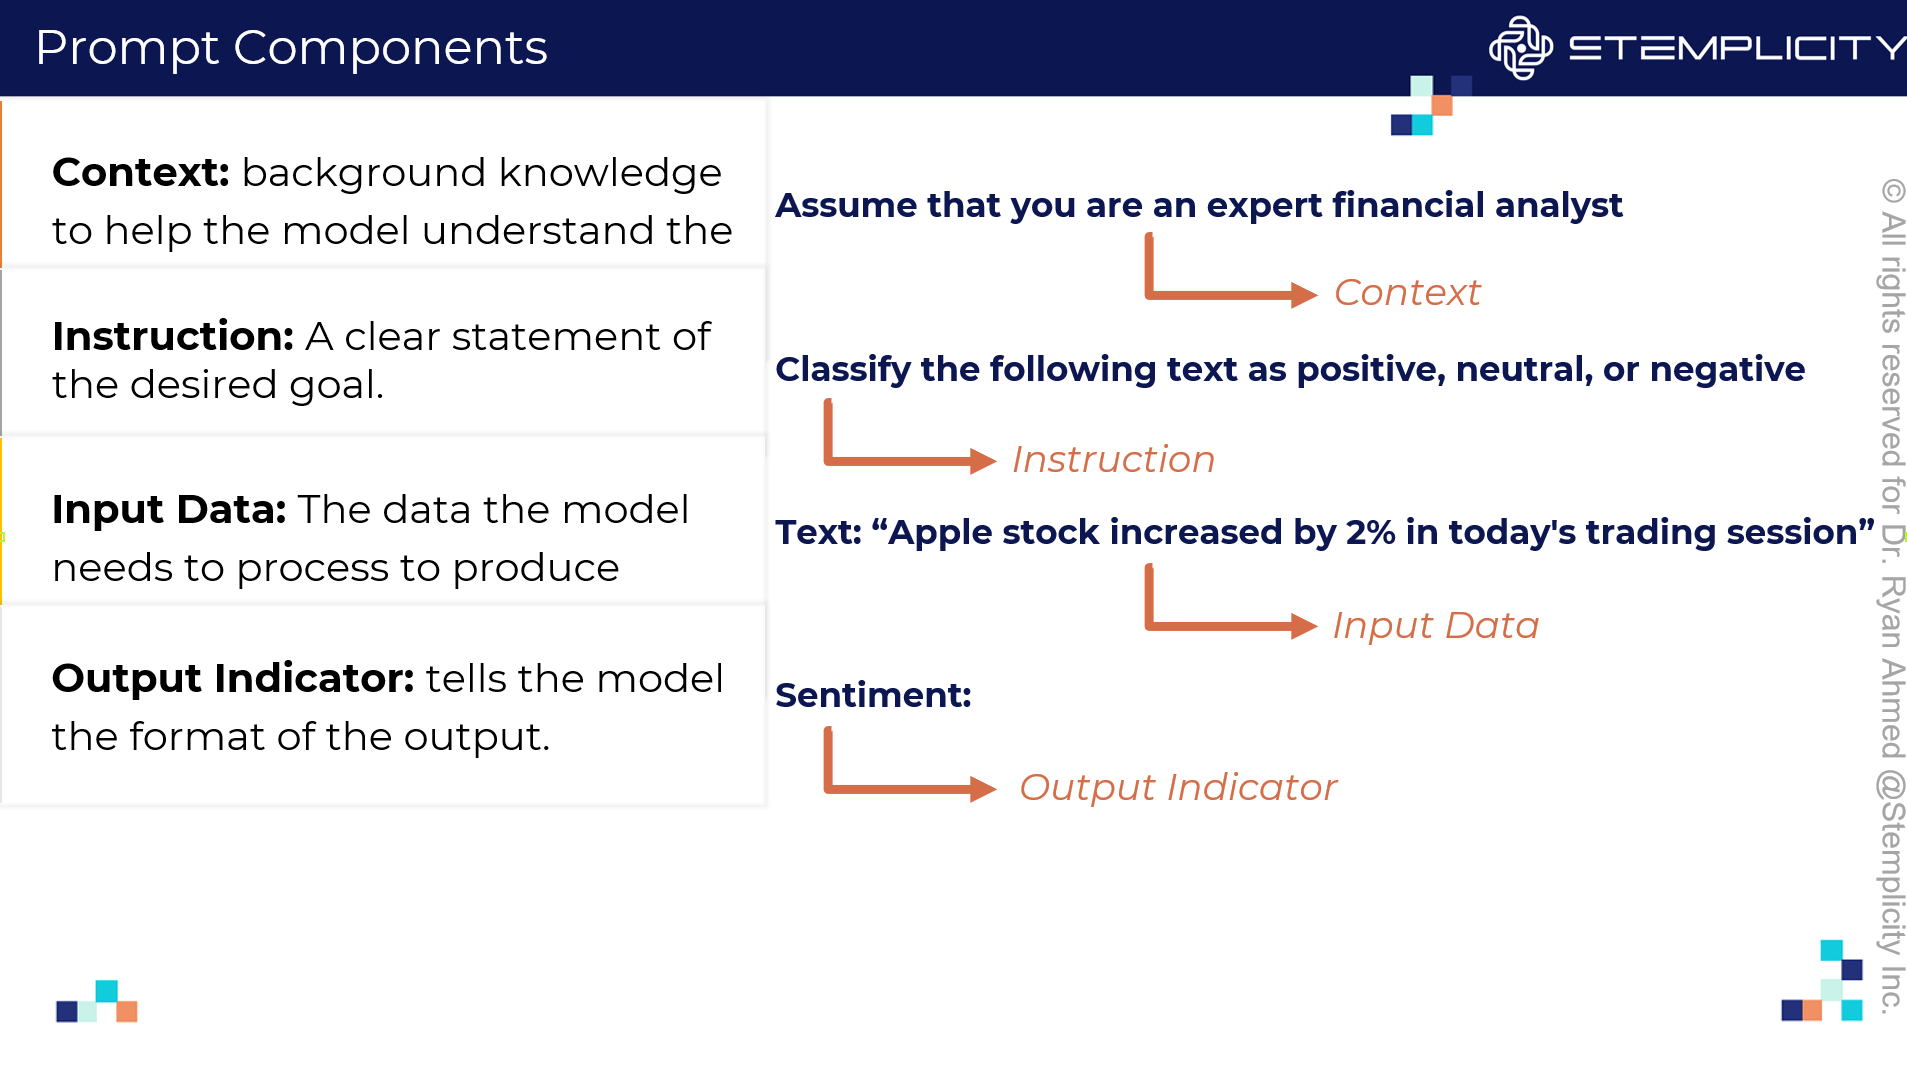

In [17]:
# Import the OpenAI API client
from openai import OpenAI 

# Import the Agent class to create and manage AI agents
from agents import Agent

# Define the instructions for the fact-checker AI Agent
fact_checker_instructions = """
Context:
You are a fact-checker who verifies the accuracy of statements.

Instructions:
When given a statement, carefully analyze its factual accuracy using your knowledge.

Input:
You will receive a statement that requires fact-checking.

Output:
Respond with:
1. A verdict prefix: either "✅ TRUE:" or "❌ FALSE:"
2. A brief, one-sentence explanation justifying your conclusion
"""


In [18]:
# Create a new agent called "Fact Checker"
fact_checker_agent = Agent(name = "Fact Checker",   # Name of the agent
                           instructions = fact_checker_instructions, # The rules and behavior for the agent
                           model = "openai/gpt-oss-20b:free") # The AI model (LLM) to use

# Print a confirmation message that the agent was created
print(f"Agent '{fact_checker_agent.name}' created successfully!")

Agent 'Fact Checker' created successfully!


Let's put our `fact_checker_agent` to work! We'll use the `Runner.run()` method to send it a statement to fact-check. The agent will analyze the statement and return its verdict along with a brief explanation.

In [19]:
# Import the Runner class, which is used to run an agent and get its output
from agents import Runner

# A statement we want the Fact Checker agent to verify
statement = "The Great Wall of China is visible from space with the naked eye."

# Display the statement we're going to check (in markdown format for nicer formatting)
print_markdown(f"Asking the Fact Checker to verify: '{statement}'")

# Run the Fact Checker agent on the input statement
# 'await' is used because running the agent is an asynchronous operation (it might take time)
response = await Runner.run(
    starting_agent = fact_checker_agent,  # The agent we created earlier
    input = statement                 # The statement we want it to fact-check
)

# Display the agent's response
print_markdown("\n🤖 Agent's Response:\n")
print_markdown(response.final_output)    # Shows the final verdict and explanation

Asking the Fact Checker to verify: 'The Great Wall of China is visible from space with the naked eye.'


🤖 Agent's Response:


❌ FALSE: While the Great Wall is a massive structure, it is too narrow and blends with its surrounding terrain to be discernible with the unaided eye from Earth's orbit.

**PRACTICE OPPORTUNITY:** 
- **Now it's your turn to experiment with OpenAI API Agents SDK; perform the following tasks:**
   - **Change the text inside the `statement` variable. Try a different fact, like `"The tallest mountain in the world is Mount Everst"` See how the AI agent responds!**
   - **Try a different AI model, change the model from `model="gpt-4o-mini"` to `model="gpt-5-mini"`**

In [ ]:
from agents import Agent, Runner

fact_checker_practice_agent = Agent(name="fact_check_practice_agent", instructions= fact_checker_instructions, model="openai/gpt-oss-120b")

practice_statement = "Homeopathy is purely based on Scientific method for treatment."

# Display the statement we're going to check (in markdown format for nicer formatting)
print_markdown(f"Asking the Fact Checker to verify: '{practice_statement}'")

responses = await Runner.run(
    starting_agent = fact_checker_practice_agent,
    input = practice_statement
)

# Display the agent's response
print_markdown("\n🤖 Agent's Response:\n")
print_markdown(responses.final_output)

Asking the Fact Checker to verify: 'Homeopathy is purely based on Scientific method for treatment.'


🤖 Agent's Response:


❌ FALSE: Homeopathy is not based on the scientific method; it relies on principles that lack empirical support and are not scientifically validated.

## TASK 4. CHECK IF THE AI AGENT CAN RECALL INFORMATION (NO MEMORY) & CHECK TRACES

In [24]:
check_recall_statement = "What did we discuss in the last message?"

response = await Runner.run(starting_agent = fact_checker_agent, input = check_recall_statement)
print_markdown("\n🤖 Agent's Response:\n")
print_markdown(response.final_output)


🤖 Agent's Response:


❌ FALSE: The sentence “What did we discuss in the last message?” is a question, not a factual claim, so it cannot be judged true or false.

- **Note: You can monitor what the Agent did through traces, available in the OpenAI platform when you log in to your account.**
- **Link: https://platform.openai.com/logs/**

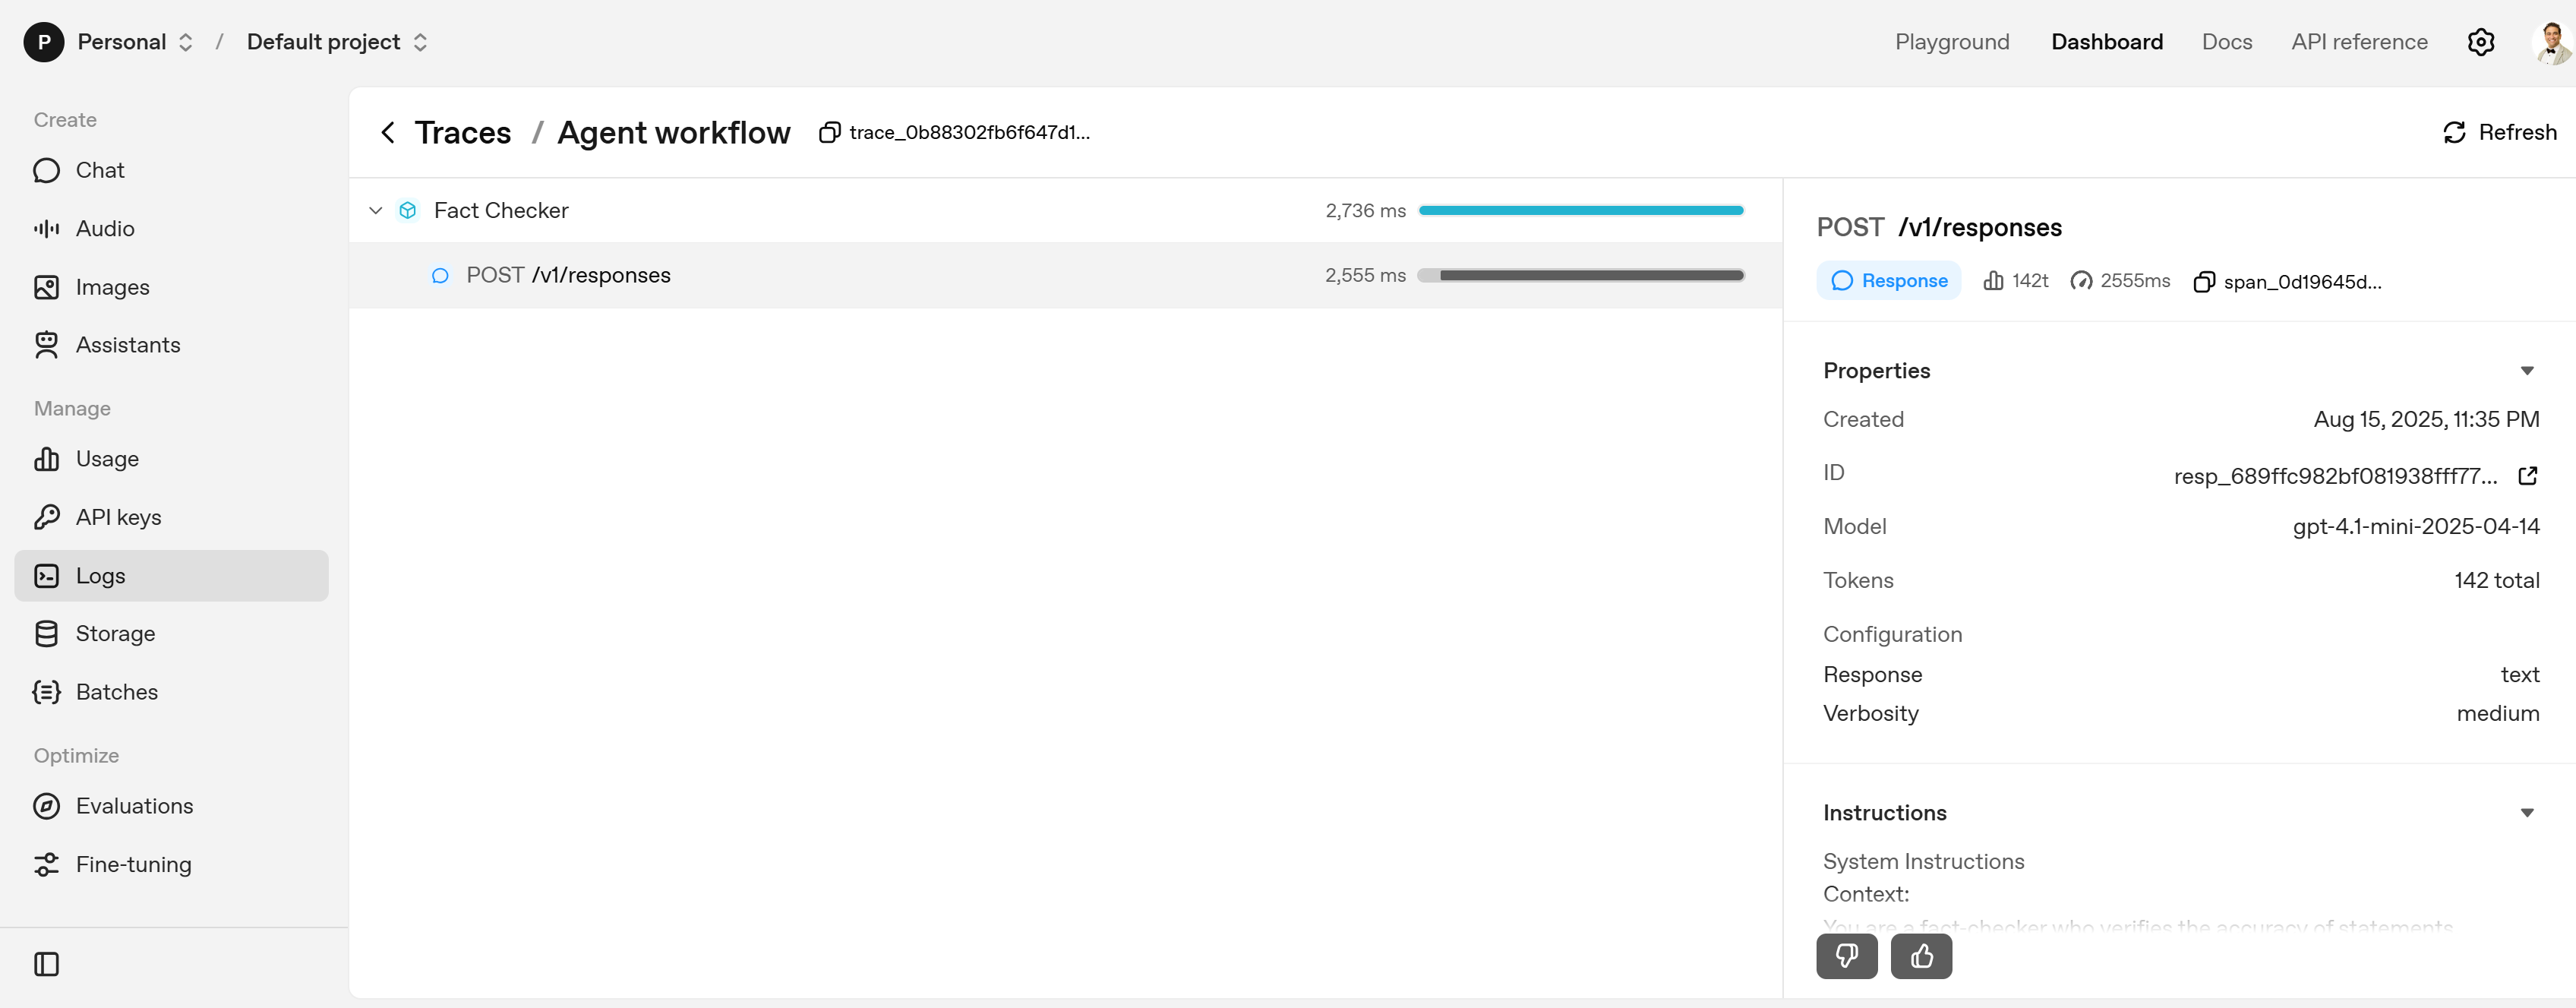

**OpenAI Tokenizer: https://platform.openai.com/tokenizer**

**PRACTICE OPPORTUNITY:** 
- **Create a new AI agent named `Tweet Bot` that writes a creative, engaging tweet (≤280 characters) about a given topic using OpenAI Agents SDK. The tweet should include at least one emoji and a hashtag.**
    - **1. Set Up Instructions: Define `Tweet Bot`’s purpose and personality, and configure it to use the latest `gpt-5-mini` model**.  
    - **2. Choose a Topic: For example use "The future of renewable energy"**.  
    - **3. Run the Agent: Use `Runner.run()` to execute the agent and print the generated tweet. Use traces to track the Agent behaviour and list the number of input and output tokens used.**

In [36]:
from agents import Agent, Runner

instructions = """
Context: You are an experienced copy-writer with expertise in optimizing content for social media for click bait and higher reach.

Instruction: Write a tweet for X (formerly, Twitter) on the topic provided.

Input: A topic to write tweet for.

Output: A highly optimized twitter tweet considering following conditions:
1. Write an engaging tweet in <= 280 characters
2. The tweet must contain at least one emoji and a hashtag
"""

tweet_bot_agent_practice = Agent(
    name = "tweet_bot_agent",
    instructions = instructions,
    model = "nemotron-3-nano-omni-30b-a3b-reasoning:free"
)

tweet_topic = "MS Dhoni"

response = await Runner.run(
    starting_agent = tweet_bot_agent_practice,
    input = tweet_topic
)

print_markdown(f"Writing engaging tweet on: {tweet_topic}")
print_markdown("\n🤖 Agent's Response:\n")
print_markdown(response.final_output)



Writing engaging tweet on: MS Dhoni


🤖 Agent's Response:


🔥 MS Dhoni just turned the stadium into a CSK playground! 🏏✨ From the iconic helicopter to the calm finish, his legacy is pure gold. Who else loves ‘Thala’? #MSDhoni #CricketMagic

# PRACTICE OPPORTUNITY SOLUTIONS

**PRACTICE OPPORTUNITY SOLUTION:** 
- **Now it's your turn to experiment with OpenAI API Agents SDK; perform the following tasks:**
   - **Change the text inside the `statement` variable. Try a different fact, like `"The tallest mountain in the world is Mount Everst"` See how the AI agent responds!**
   - **Try a different AI model, change the model from `model="gpt-4o-mini"` to `model="gpt-5-mini"`**

**OpenAI Models: https://platform.openai.com/docs/models**

In [ ]:
# Create a new agent called "Fact Checker"
fact_checker_agent = Agent(name = "Fact Checker",   # Name of the agent
                           instructions = fact_checker_instructions, # The rules and behavior for the agent
                           model = "gpt-5-mini") # The AI model (LLM) to use

# Print a confirmation message that the agent was created
print(f"Agent '{fact_checker_agent.name}' created successfully!")

In [ ]:
# Import the Runner class, which is used to run an agent and get its output
from agents import Runner

# A statement we want the Fact Checker agent to verify
statement = "The tallest mountain in the world is Mount Everst"

# Display the statement we're going to check (in markdown format for nicer formatting)
print_markdown(f"Asking the Fact Checker to verify: '{statement}'")

# Run the Fact Checker agent on the input statement
# 'await' is used because running the agent is an asynchronous operation (it might take time)
response = await Runner.run(
    starting_agent = fact_checker_agent,  # The agent we created earlier
    input = statement                 # The statement we want it to fact-check
)

# Display the agent's response
print_markdown("\n🤖 Agent's Response:\n")
print_markdown(response.final_output)    # Shows the final verdict and explanation

**PRACTICE OPPORTUNITY SOLUTION:** 
- **Create a new AI agent named `Tweet Bot` that writes a creative, engaging tweet (≤280 characters) about a given topic using OpenAI Agents SDK. The tweet should include at least one emoji and a hashtag.**
    - **1. Set Up Instructions: Define `Tweet Bot`’s purpose and personality, and configure it to use the latest `gpt-5-mini` model**.  
    - **2. Choose a Topic: For example use "The future of renewable energy"**.  
    - **3. Run the Agent: Use `Runner.run()` to execute the agent and print the generated tweet. Use traces to track the Agent behaviour and list the number of input and output tokens used.**

In [7]:
tweet_bot_instructions = """
Instruction:
Write a short, engaging tweet (≤280 characters) about the given topic. The tweet must include at least one relevant emoji and one relevant hashtag.

Context:
You are **TweetBot**, a witty and creative social-media expert known for crafting viral tweets.

Input:
A topic provided by the user.

Output:
A single tweet (≤280 characters) about the topic, containing at least one relevant emoji and one relevant hashtag.
"""


In [8]:
# Let's define the Agent
tweet_bot_agent = Agent(name = "Tweet Bot",
                        instructions = tweet_bot_instructions,
                        model = "gpt-5-mini")
print(f"Agent '{tweet_bot_agent.name}' created successfully!")


Agent 'Tweet Bot' created successfully!


In [9]:
# Let's run the agent and test it out!
topic = "The future of renewable energy"
print_markdown(f"\nAsking Tweet Bot to write a tweet about: '{topic}'")

tweet_response = await Runner.run(starting_agent=tweet_bot_agent, input=topic)
print_markdown("\n🤖 Tweet Bot's Response:\n")
print_markdown(tweet_response.final_output)


Asking Tweet Bot to write a tweet about: 'The future of renewable energy'


🤖 Tweet Bot's Response:


Sun, wind and storage aren't just trends—they're the power shift. 🌞🌬️🔋 The future of renewable energy is smart, local, and unstoppable. Ready to plug into a cleaner tomorrow? ⚡️🌍 #Renewables #CleanEnergy

- **Would love to connect with everyone on LinkedIn: www.linkedin.com/in/dr-ryan-ahmed**

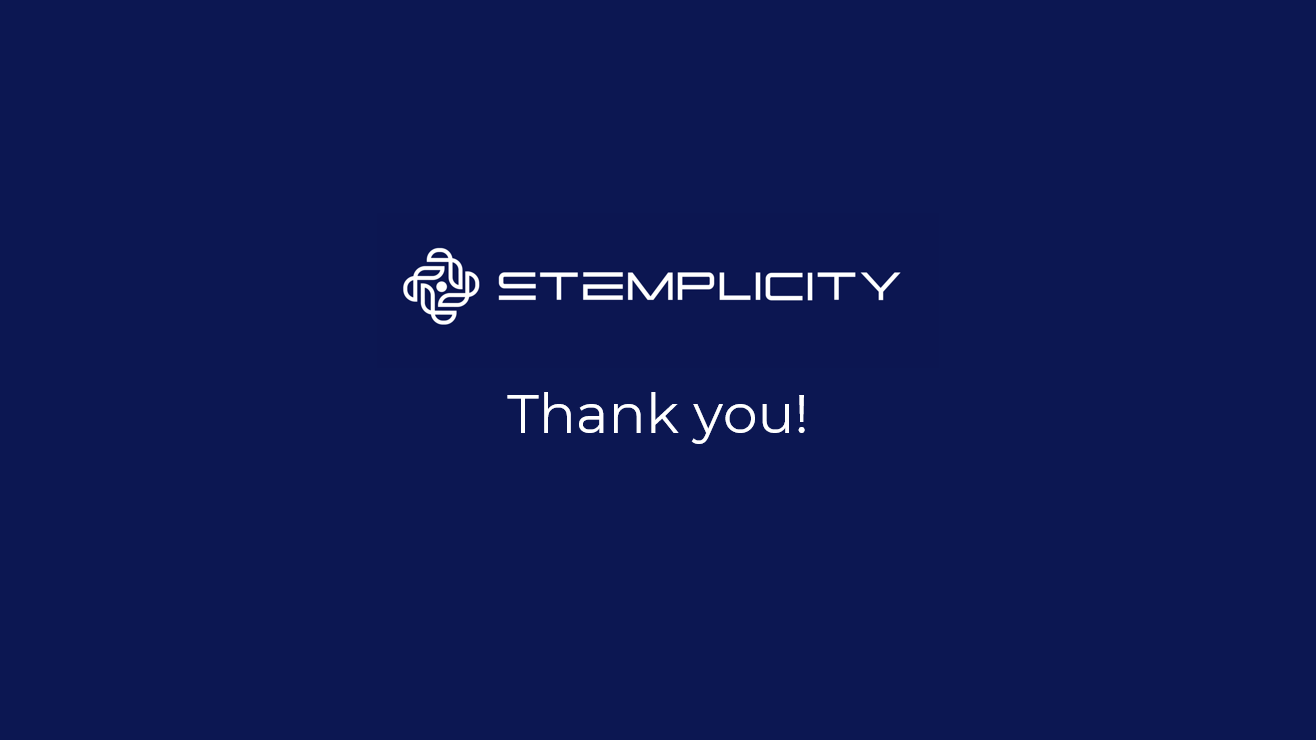